# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [46]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [47]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [48]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [49]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [50]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [51]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", plans.shape)
print("usage", plans.shape)

plans (2, 8)
users (2, 8)
usage (2, 8)


In [52]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [53]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [54]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [55]:
# cantidad de nulos para users
print("Nulos de ciudad")
print(users["city"].isna().sum())
print(users["city"].isna().mean())
print("Nulos de tasa de cancelación")
print(users["churn_date"].isna().sum())
print(users["churn_date"].isna().mean())

Nulos de ciudad
469
0.11725
Nulos de tasa de cancelación
3534
0.8835


In [56]:
# cantidad de nulos para usage
print("Nulos de fecha")
print(usage["date"].isna().sum())
print(usage["date"].isna().mean())
print("Nulos de duración")
print(usage["duration"].isna().sum())
print(usage["duration"].isna().mean())
print("Nulos de extención")
print(usage["length"].isna().sum())
print(usage["length"].isna().mean())

Nulos de fecha
50
0.00125
Nulos de duración
22076
0.5519
Nulos de extención
17896
0.4474


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- Las columnas city y churn_date del dataset users tienen valores faltantes. La primera tiene 11% de faltantes, mientras que la segunda tiene 88%
- Las columnas date, duration y lenght del data set usage tienen valores faltantes. Date tiene una cantidad insignificante de faltantes (>1%). Por otro lado, duration y lengtth tienen 55% y 44% de faltantes respectivamente.
- En el caso de city es importante confirmar si la ubicación es un factor relevante para el análisis de comportamiento de uso de los clientes. En el caso de la tasa de cancelación al ser un porcentaje muy alto, se recomienda revisar el proceso de recopilación de datos para validar si existe un error.
- Los valores faltantes de date se pueden eliminar al ser mínima la proporción. En el caso de duration y length se recomienda investigar para imputar o dejar como nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [57]:
# explorar columnas numéricas de users
print ("Exploración columna user_id")
print(users["user_id"].describe())
print ("Exploración columna age")
print(users["age"].describe())

Exploración columna user_id
count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64
Exploración columna age
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


- La columna `user_id` es un identificador, por lo cual no es necesario incluirlo en el análisis 
- La columna `age` contiene sentinels (-999), los cuales probablemente esten afectando las medidas estadísticas

In [58]:
# explorar columnas numéricas de usage
print ("Exploración columna id")
print(usage["id"].describe())
print ("Exploración columna user_id")
print(usage["user_id"].describe())
print ("Exploración columna duration")
print(usage["duration"].describe())
print ("Exploración columna length")
print(usage["length"].describe())

Exploración columna id
count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64
Exploración columna user_id
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64
Exploración columna duration
count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64
Exploración columna length
count    22104.000000
mean        52.127398
std         56.611183
min          0.000000
25%         37.000000
50%         50.000000
75%         64.000000
max       1490.000000
Name: length, dtype: float64


- Las columnas `id` y `user_id` son identificadores, por lo cual no es necesario incluirlos en el análisis 
- Las columnas `duration` y `length` presentan una variación estándar significativa, asi como valores máximos altos en comparación con los cuartiles por lo que deben revisarse detenidamente

In [59]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` contiene sentinels ("?")
- La columna `plan` no presenta valores atípicos

In [60]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` no presenta valores atípicos


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- Se contraton sentiles en la columna city, se recomienda convertiles en valores nulos al ser una cantidad baja de casos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [61]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"],errors="coerce")

In [62]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"],errors="coerce")

In [63]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [64]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- En la columna reg_date se registraro fechas del 2026, el cual no ha transcurrido al momento de guardar los datos. Se recomienda eliminarlos.
- En la columna date no se presentan errores de captura


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [65]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [66]:
# Reemplazar ? por NA en city
users["city"]=users["city"].replace("?",pd.NA)

# Verificar cambios
users["city"].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [67]:

# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year==2026, "reg_date"] = pd.NaT

# Verificar cambios
users["reg_date"].dt.year.value_counts()


2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [68]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean().sort_values()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [69]:

# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean().sort_values()


type
text    0.00000
call    0.99933
Name: length, dtype: float64

Los valores nulos de ambas columnas no son errores, son estructuralmente correctos porque duration corresponde a la duración de la llamada y length a la longitud del texto, por lo que se pueden dejar como nulos en ambos casos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [70]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby(usage["user_id"],dropna=False).agg({"is_text":"sum","is_call":"sum","duration":"sum"}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [71]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={"is_text":"cant_mensajes","is_call":"cant_llamadas","duration":"cant_min_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_min_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [72]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg, on=["user_id"], how="left")

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_min_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [73]:
# Resumen estadístico de las columnas numéricas
user_profile[["age","cant_mensajes","cant_llamadas","cant_min_llamada"]].describe()

,age,cant_mensajes,cant_llamadas,cant_min_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [74]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

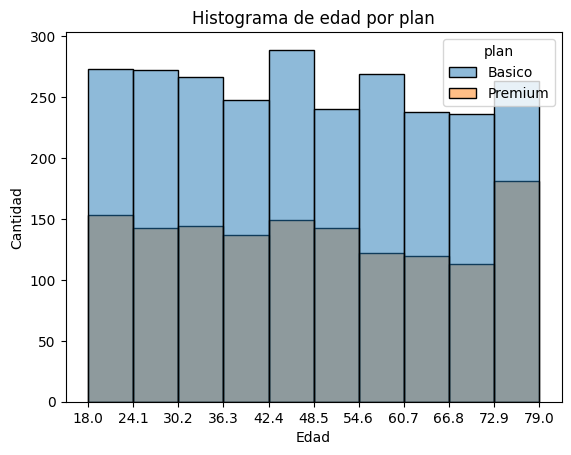

In [75]:

# Histograma para visualizar la edad (age)

bin_edges = np.linspace(18, 79, 11)
sns.histplot(data=user_profile, x="age", hue="plan", bins=10)
plt.xticks(bin_edges)
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.title("Histograma de edad por plan")
plt.show()



💡Insights: 
- La distribución en el plan básico esta ligeramente sesgada a la derecha. La mayoría de los clientes se encuentran endos rangos, de 42 a 49 y de 54 a 61 años.
- La distribución en el plan premium presenta un sesgo a la izquierda. Con una concentración importante en el rango de 72 a 79 años.

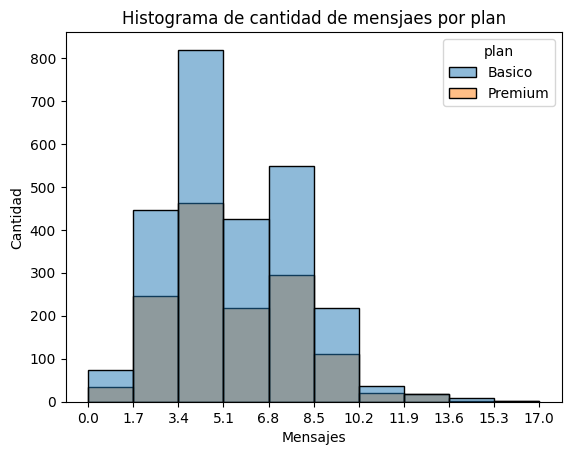

In [76]:
# Histograma para visualizar la cant_mensajes
bin_edges = np.linspace(0, 17, 11)
sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", bins=10)
plt.xticks(bin_edges)
plt.xlabel("Mensajes")
plt.ylabel("Cantidad")
plt.title("Histograma de cantidad de mensjaes por plan")
plt.show()


💡Insights: 
- En ambos tipos de planes la distribución de se encuentra sesgada a la derecha

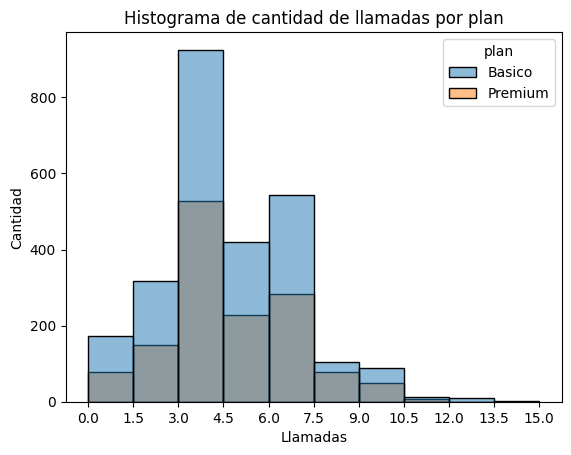

In [77]:
# Histograma para visualizar la cant_llamadas
bin_edges = np.linspace(0, 15, 11)
sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", bins=10)
plt.xticks(bin_edges)
plt.xlabel("Llamadas")
plt.ylabel("Cantidad")
plt.title("Histograma de cantidad de llamadas por plan")
plt.show()


💡Insights: 
- En ambos tipos de planes al distribución se encuentra sesgada a la derecha

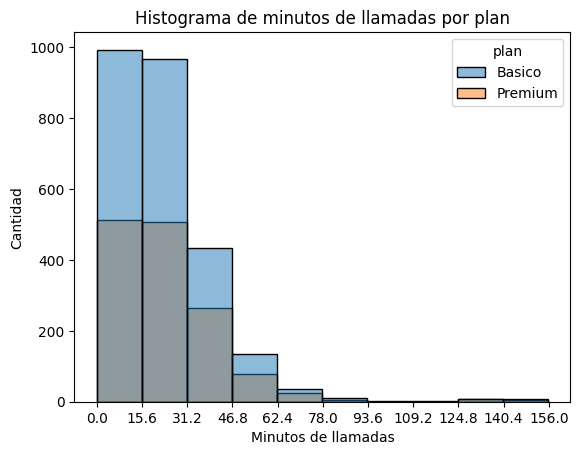

In [78]:
# Histograma para visualizar la cant_minutos_llamada
bin_edges = np.linspace(0, 156, 11)
sns.histplot(data=user_profile, x="cant_min_llamada", hue="plan", bins=10)
plt.xticks(bin_edges)
plt.xlabel("Minutos de llamadas")
plt.ylabel("Cantidad")
plt.title("Histograma de minutos de llamadas por plan")
plt.show()


💡Insights: 
- En ambos tipos de planes la distribución se encuentra sesgada a la derecha

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

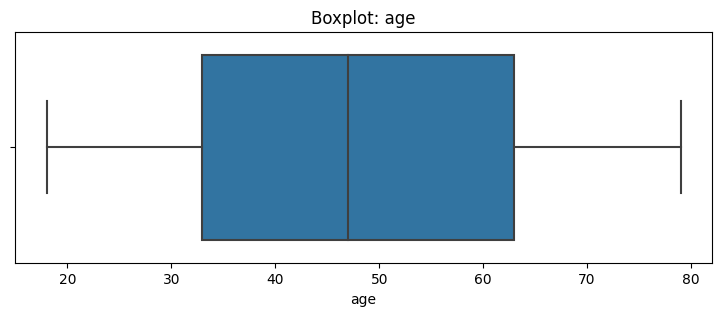

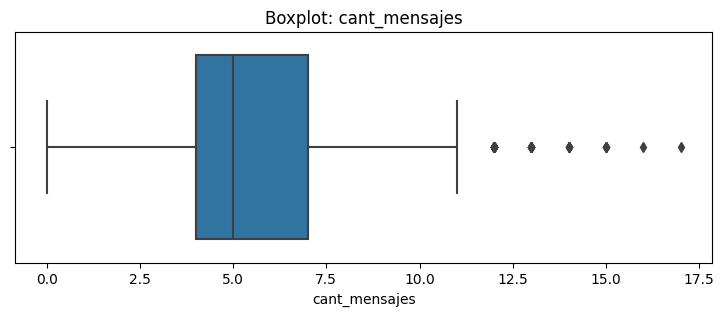

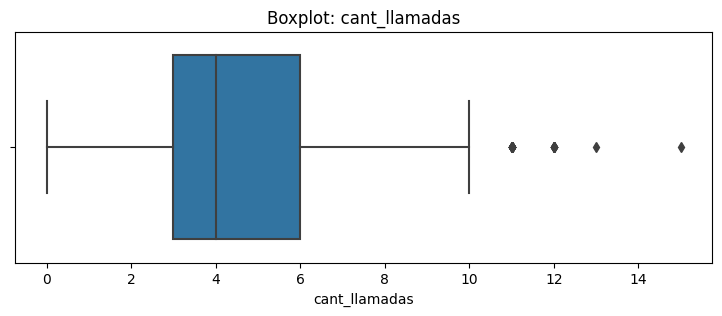

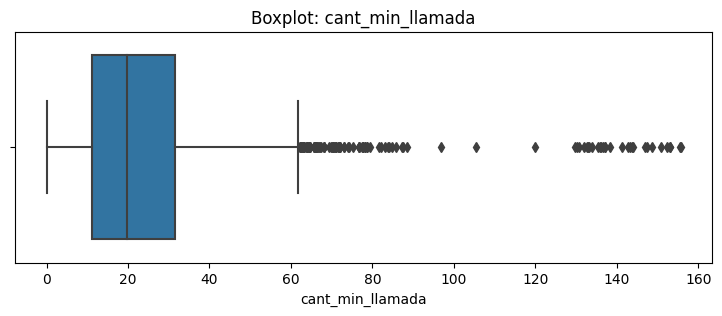

In [79]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_min_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(9,3))
    sns.boxplot(x=user_profile[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: Presenta outliers
- cant_llamadas: Presenta outliers
- cant_minutos_llamada: Presenta outliers

In [80]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_min_llamada']
for col in columnas_limites:
    Q1= user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR=Q3-Q1
    upper=Q3+1.5*IQR
    print (f"Limite en {col}:{upper}")


Limite en cant_mensajes:11.5
Limite en cant_llamadas:10.5
Limite en cant_min_llamada:61.8575


In [81]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_min_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantener outliers, ya que aunque son casos raros, es posible que un cliente haya tenido este comportamiento
- cant_llamadas: Mantener outliers, ya que aunque son casos raros, es posible que un cliente haya tenido este comportamiento
- cant_minutos_llamada: Mantener outliers, ya que aunque son casos raros, es posible que un cliente haya tenido este comportamiento

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [82]:

# Crear columna grupo_uso
def clasiffy_segment_use (col):
    mensajes =col["cant_mensajes"]
    llamadas=col["cant_llamadas"]
    if pd.isna(mensajes) or pd.isna(llamadas):
        return "Error en datos"
    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"
    if llamadas < 10 and mensajes < 10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile["grupo_uso"]=user_profile.apply(clasiffy_segment_use,axis=1)


        

In [83]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_min_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [84]:
# Crear columna grupo_edad
def clasiffy_segment_age (col):
    edad =col["age"]
    if pd.isna(edad):
        return "Error en datos"
    if edad < 30:
        return "Joven"
    if edad < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile["grupo_edad"]=user_profile.apply(clasiffy_segment_age,axis=1)


In [85]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_min_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

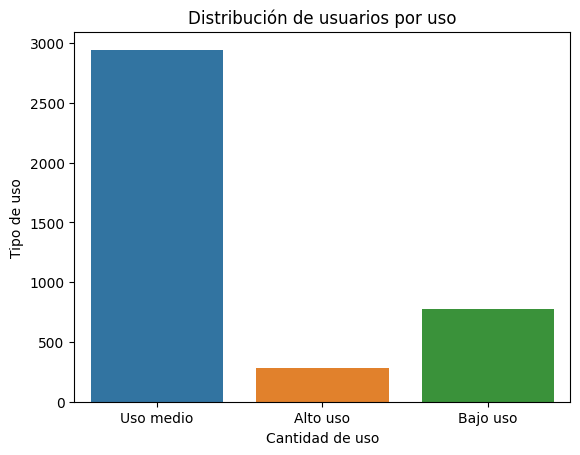

In [86]:
# Visualización de los segmentos por uso
grupo_uso_filtrado=user_profile[user_profile["grupo_uso"]!="Error en datos"]
sns.countplot(data=grupo_uso_filtrado, x="grupo_uso")
plt.title("Distribución de usuarios por uso")
plt.xlabel("Cantidad de uso")
plt.ylabel("Tipo de uso")

plt.show()

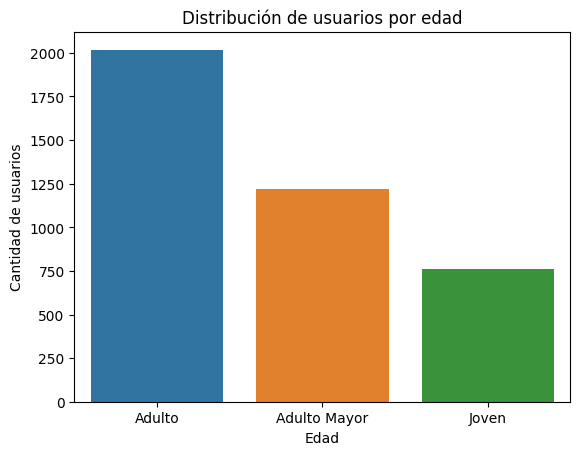

In [87]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad")
plt.title("Distribución de usuarios por edad")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores faltantes: En el dataset users se encontraron valores faltantes en las columnas city y churn date, con 11% y 88% de faltantes respectivamente. En ambos casos se recomienda revisar el proceso de recopilación de datos para validar si existe un error. Para fines del presente análisis la información no es relevante por lo cual se dejaron como valores nulos. De igual forma la columna city presentaba sentinels los cuales se modificaron como valores nulos.

- Por otro lado en el dataset usage la columna date tenia menos de 1% de faltantes, mientras que duration y length tenían 55% y 44% de faltantes. Al ser despreciable el porcentaje en la columna date, se eliminaron los valores nulos. Cabe mencionar que se eliminaron las fechas imposibles, en particular aquellos registros del 2026, al no haber transcurrido este año al momento de recabar el dataset. En el caso de duration y lenght se confirmó que los valores faltantes estuvieran justificados por la naturaleza de la información; donde solo se registra duración para las llamdas y lenght para los mensajes de texto. 


🔍 **Segmentos por Edad**
- Uno de los segmentos de clientes es la edad, donde los usuarios jovenes son aquellos con menos de 30 años, los adultos de 30 a 60 y los adultos mayores son aquellos mayores a 60 años. En el caso de ConnectaTel el principal segmento es el de adultos, seguido por el de adultos mayores y en menor proporción por el de jovenes

📊 **Segmentos por Nivel de Uso**
- El segmento líder por margen amplio es el de uso medio, seguido por el uso bajo y en menor medida uso alto.


➡️ Esto sugiere que ...
- Se identidica que la mayoría de la base ha adoptado el plan premium, en su mayoría conformado por el segmento de aldultos mayores.
- Tanto para la cantidad de mensajes enviados y llamadas realizadas existten heavy users. En caso de estar en plan básico se recomienda migrarlos a premium; de ser premium revisar si el plan tiene techo o es ilimitado para determinar siguientes acciones. 

💡 **Recomendaciones**
- Implementar programas de lealtad, promoviendo beneficios exclusivos y atención preferencial para usuarios, en especial en aquellos casos donde los usuarios tengan más de 12 meses.
- Oferecer una oferta de migración a los usuarios en plan básico donde tengan más de 5 mensajes y 4 llamadas. Esto puede ser mediante una oferta donde se les bonifique el primer mes o se les ofrezca el cambio de manera gratuita.
- A los usuarios con mayor cantidad de minutos (+120) ofrecer un add-on de minutos extendidos, con el fin de mejorar su experiencia sin rediseñar el plan base.
- Ofrecer una variante al adulto mayor premium, segmento que probablemente no utilice extensivamente los mensajes, pero si las llamadas. Ofrecer más minutos y menos elementos digitales para promover su retención.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`